In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, classification_report, roc_auc_score


In [2]:
df = pd.read_csv("BankChurners.csv")

print(df.shape)
df.head()

(10127, 23)


,CLIENTNUM,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,...,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2
0,768805383,Existing Customer,45,M,3,High School,Married,$60K - $80K,Blue,39,...,12691.0,777,11914.0,1.335,1144,42,1.625,0.061,0.000093,0.99991
1,818770008,Existing Customer,49,F,5,Graduate,Single,Less than $40K,Blue,44,...,8256.0,864,7392.0,1.541,1291,33,3.714,0.105,0.000057,0.99994
2,713982108,Existing Customer,51,M,3,Graduate,Married,$80K - $120K,Blue,36,...,3418.0,0,3418.0,2.594,1887,20,2.333,0.000,0.000021,0.99998
3,769911858,Existing Customer,40,F,4,High School,Unknown,Less than $40K,Blue,34,...,3313.0,2517,796.0,1.405,1171,20,2.333,0.760,0.000134,0.99987
4,709106358,Existing Customer,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,...,4716.0,0,4716.0,2.175,816,28,2.500,0.000,0.000022,0.99998


In [3]:
df = df.drop(["CLIENTNUM"], axis=1)

In [4]:
df = df.drop([
    "Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1",
    "Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2"
], axis=1)

In [5]:
df["Attrition_Flag"] = df["Attrition_Flag"].map({
    "Existing Customer": 0,
    "Attrited Customer": 1
})

In [10]:
df = df.dropna()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10127 entries, 0 to 10126
Data columns (total 33 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Attrition_Flag                  10127 non-null  int64  
 1   Customer_Age                    10127 non-null  int64  
 2   Dependent_count                 10127 non-null  int64  
 3   Months_on_book                  10127 non-null  int64  
 4   Total_Relationship_Count        10127 non-null  int64  
 5   Months_Inactive_12_mon          10127 non-null  int64  
 6   Contacts_Count_12_mon           10127 non-null  int64  
 7   Credit_Limit                    10127 non-null  float64
 8   Total_Revolving_Bal             10127 non-null  int64  
 9   Avg_Open_To_Buy                 10127 non-null  float64
 10  Total_Amt_Chng_Q4_Q1            10127 non-null  float64
 11  Total_Trans_Amt                 10127 non-null  int64  
 12  Total_Trans_Ct                  

In [8]:
df = pd.get_dummies(df, drop_first=True)
X = df.drop("Attrition_Flag", axis=1)
y = df["Attrition_Flag"]

In [12]:
## Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [13]:
log_model = LogisticRegression(max_iter=1000, class_weight='balanced')

log_model.fit(X_train_scaled, y_train)

y_pred_log = log_model.predict(X_test_scaled)

In [14]:
acc_log = accuracy_score(y_test, y_pred_log)

print("Logistic Accuracy:", acc_log)
print(classification_report(y_test, y_pred_log))

roc_log = roc_auc_score(y_test, log_model.predict_proba(X_test_scaled)[:,1])
print("Logistic ROC-AUC:", roc_log)

Logistic Accuracy: 0.8548864758144127
              precision    recall  f1-score   support

           0       0.96      0.86      0.91      1701
           1       0.53      0.82      0.64       325

    accuracy                           0.85      2026
   macro avg       0.75      0.84      0.78      2026
weighted avg       0.89      0.85      0.87      2026

Logistic ROC-AUC: 0.9206692895581785


In [17]:
rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    random_state=42
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
acc_rf = accuracy_score(y_test, y_pred_rf)

print("Random Forest Accuracy:", acc_rf)
print(classification_report(y_test, y_pred_rf))

roc_rf = roc_auc_score(y_test, rf_model.predict_proba(X_test)[:,1])
print("Random Forest ROC-AUC:", roc_rf)

Random Forest Accuracy: 0.9442250740375123
              precision    recall  f1-score   support

           0       0.95      0.99      0.97      1701
           1       0.93      0.71      0.80       325

    accuracy                           0.94      2026
   macro avg       0.94      0.85      0.89      2026
weighted avg       0.94      0.94      0.94      2026

Random Forest ROC-AUC: 0.9803228869895536


In [65]:
from sklearn.svm import SVC

svm_model = SVC(
    kernel='rbf',
    C=1.0,
    gamma='scale',
    probability=True,
    random_state=42
)

svm_model.fit(X_train_scaled, y_train)

y_pred_svm = svm_model.predict(X_test_scaled)
acc_svm = accuracy_score(y_test, y_pred_svm)

print("SVM Accuracy:", acc_svm)
print(classification_report(y_test, y_pred_svm))

roc_svm = roc_auc_score(y_test, svm_model.predict_proba(X_test_scaled)[:,1])
print("SVM ROC-AUC:", roc_svm)

SVM Accuracy: 0.9155972359328727
              precision    recall  f1-score   support

           0       0.92      0.98      0.95      1701
           1       0.87      0.56      0.68       325

    accuracy                           0.92      2026
   macro avg       0.90      0.77      0.82      2026
weighted avg       0.91      0.92      0.91      2026

SVM ROC-AUC: 0.9431800298466966


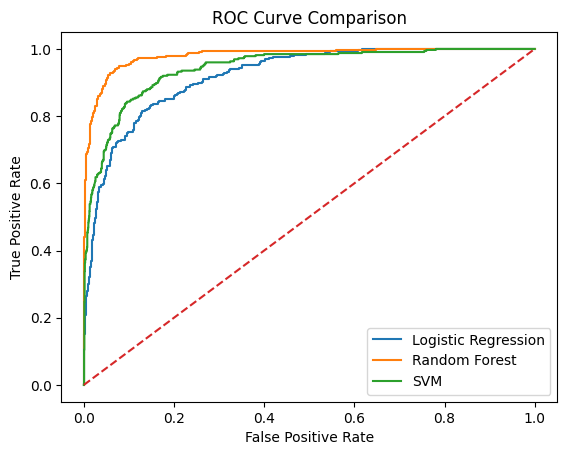

In [66]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve

# Logistic Regression
log_probs = log_model.predict_proba(X_test_scaled)[:,1]
fpr_log, tpr_log, _ = roc_curve(y_test, log_probs)

# Random Forest
rf_probs = rf_model.predict_proba(X_test)[:,1]
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_probs)

# SVM
svm_probs = svm_model.predict_proba(X_test_scaled)[:,1]
fpr_svm, tpr_svm, _ = roc_curve(y_test, svm_probs)

# Plot
plt.figure()

plt.plot(fpr_log, tpr_log, label="Logistic Regression")
plt.plot(fpr_rf, tpr_rf, label="Random Forest")
plt.plot(fpr_svm, tpr_svm, label="SVM")

plt.plot([0,1], [0,1], linestyle='--')  # baseline

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")

plt.legend()
plt.show()

In [67]:
from sklearn.metrics import confusion_matrix

print("\nConfusion Matrix (Logistic Regression):")
print(confusion_matrix(y_test, y_pred_log))

print("\nConfusion Matrix (Random Forest):")
print(confusion_matrix(y_test, y_pred_rf))

print("\nConfusion Matrix (SVM):")
print(confusion_matrix(y_test, y_pred_svm))


Confusion Matrix (Logistic Regression):
[[1466  235]
 [  59  266]]

Confusion Matrix (Random Forest):
[[1683   18]
 [  95  230]]

Confusion Matrix (SVM):
[[1674   27]
 [ 144  181]]



Top 10 Important Features:
Total_Trans_Ct              0.185763
Total_Trans_Amt             0.177544
Total_Ct_Chng_Q4_Q1         0.114346
Total_Revolving_Bal         0.113134
Avg_Utilization_Ratio       0.077348
Total_Relationship_Count    0.069138
Total_Amt_Chng_Q4_Q1        0.053208
Credit_Limit                0.030066
Contacts_Count_12_mon       0.029109
Avg_Open_To_Buy             0.027958
dtype: float64


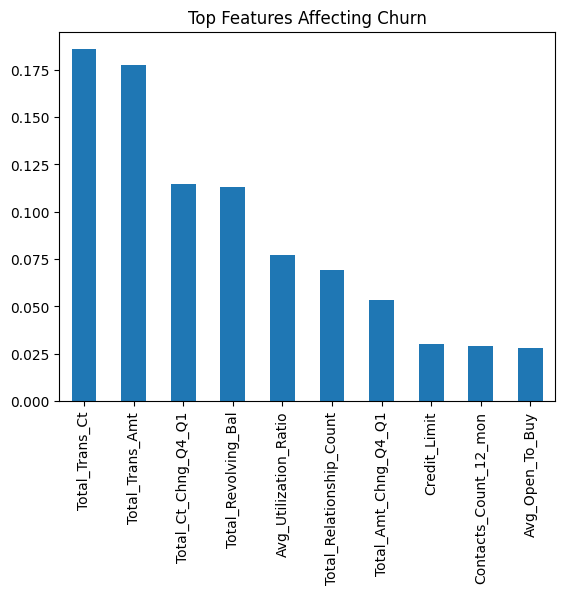

In [68]:
importance = pd.Series(rf_model.feature_importances_, index=X.columns)
importance = importance.sort_values(ascending=False)

print("\nTop 10 Important Features:")
print(importance.head(10))

# Plot
importance.head(10).plot(kind='bar')
plt.title("Top Features Affecting Churn")
plt.show()

In [69]:
def prepare_input(input_dict):
    df_input = pd.DataFrame([input_dict])
    df_input = pd.get_dummies(df_input)

    # Align columns
    df_input = df_input.reindex(columns=X.columns, fill_value=0)

    return df_input

In [70]:
def predict_dynamic(input_dict):

    # Prepare input
    input_df = pd.DataFrame([input_dict])
    input_df = pd.get_dummies(input_df)
    input_df = input_df.reindex(columns=X.columns, fill_value=0)

    # Scale for Logistic & SVM
    input_scaled = scaler.transform(input_df)

    # Logistic Regression
    log_prob = log_model.predict_proba(input_scaled)[0][1]
    log_pred = 1 if log_prob >= 0.5 else 0

    # Random Forest
    rf_prob = rf_model.predict_proba(input_df)[0][1]
    rf_pred = 1 if rf_prob >= 0.5 else 0

    # SVM
    svm_prob = svm_model.predict_proba(input_scaled)[0][1]
    svm_pred = 1 if svm_prob >= 0.5 else 0

    # Labels
    log_label = "Yes" if log_pred else "No"
    rf_label = "Yes" if rf_pred else "No"
    svm_label = "Yes" if svm_pred else "No"

    # 🔥 Confidence-based decision among ALL 3 models
    log_conf = abs(log_prob - 0.5)
    rf_conf = abs(rf_prob - 0.5)
    svm_conf = abs(svm_prob - 0.5)

    if rf_conf > log_conf and rf_conf > svm_conf:
        final_model = "Random Forest"
        final_label = rf_label
        final_prob = rf_prob
    elif svm_conf > log_conf and svm_conf > rf_conf:
        final_model = "SVM"
        final_label = svm_label
        final_prob = svm_prob
    else:
        final_model = "Logistic Regression"
        final_label = log_label
        final_prob = log_prob

    # Output
    print("\nPrediction output:")
    print(f"Logistic Regression -> Churn: {log_label}, Probability: {log_prob*100:.2f}%")
    print(f"Random Forest       -> Churn: {rf_label}, Probability: {rf_prob*100:.2f}%")
    print(f"SVM                 -> Churn: {svm_label}, Probability: {svm_prob*100:.2f}%")

    print(f"\nFinal ({final_model}) -> Churn: {final_label}, Probability: {final_prob*100:.2f}%")

In [71]:
customer_low = {
    "Customer_Age": 60,
    "Dependent_count": 3,
    "Months_on_book": 72,
    "Total_Relationship_Count": 6,
    "Months_Inactive_12_mon": 0,
    "Contacts_Count_12_mon": 0,
    "Credit_Limit": 20000,
    "Total_Revolving_Bal": 2000,
    "Avg_Open_To_Buy": 18000,
    "Total_Amt_Chng_Q4_Q1": 1.3,
    "Total_Trans_Amt": 4000,
    "Total_Trans_Ct": 60,
    "Total_Ct_Chng_Q4_Q1": 1.5,
    "Avg_Utilization_Ratio": 0.2
}
predict_dynamic(customer_low)


Prediction output:
Logistic Regression -> Churn: No, Probability: 0.08%
Random Forest       -> Churn: No, Probability: 5.50%
SVM                 -> Churn: No, Probability: 3.14%

Final (Logistic Regression) -> Churn: No, Probability: 0.08%


In [72]:
customer_high = {
    "Customer_Age": 40,
    "Dependent_count": 1,
    "Months_on_book": 6,
    "Total_Relationship_Count": 1,
    "Months_Inactive_12_mon": 5,
    "Contacts_Count_12_mon": 5,
    "Credit_Limit": 3000,
    "Total_Revolving_Bal": 2800,
    "Avg_Open_To_Buy": 200,
    "Total_Amt_Chng_Q4_Q1": 0.5,
    "Total_Trans_Amt": 700,
    "Total_Trans_Ct": 12,
    "Total_Ct_Chng_Q4_Q1": 0.4,
    "Avg_Utilization_Ratio": 0.9
}
predict_dynamic(customer_high)


Prediction output:
Logistic Regression -> Churn: Yes, Probability: 99.95%
Random Forest       -> Churn: Yes, Probability: 86.55%
SVM                 -> Churn: Yes, Probability: 96.48%

Final (Logistic Regression) -> Churn: Yes, Probability: 99.95%


In [73]:
customer_mid = {
    "Customer_Age": 50,
    "Dependent_count": 2,
    "Months_on_book": 24,
    "Total_Relationship_Count": 3,
    "Months_Inactive_12_mon": 2,
    "Contacts_Count_12_mon": 2,
    "Credit_Limit": 8000,
    "Total_Revolving_Bal": 4000,
    "Avg_Open_To_Buy": 4000,
    "Total_Amt_Chng_Q4_Q1": 0.9,
    "Total_Trans_Amt": 1500,
    "Total_Trans_Ct": 30,
    "Total_Ct_Chng_Q4_Q1": 0.9,
    "Avg_Utilization_Ratio": 0.5
}

predict_dynamic(customer_mid)


Prediction output:
Logistic Regression -> Churn: No, Probability: 37.02%
Random Forest       -> Churn: No, Probability: 10.42%
SVM                 -> Churn: Yes, Probability: 67.94%

Final (Random Forest) -> Churn: No, Probability: 10.42%


In [74]:
customer_o = {
    "Customer_Age": 45,
    "Dependent_count": 2,
    "Months_on_book": 42,          
    "Total_Relationship_Count": 4, # stabilize RF ↓
    "Months_Inactive_12_mon": 3,   
    "Contacts_Count_12_mon": 3,    
    "Credit_Limit": 10000,
    "Total_Revolving_Bal": 5500,   # moderate-high
    "Avg_Open_To_Buy": 4500,
    "Total_Amt_Chng_Q4_Q1": 0.9,
    "Total_Trans_Amt": 1800,
    "Total_Trans_Ct": 30,
    "Total_Ct_Chng_Q4_Q1": 0.9,
    "Avg_Utilization_Ratio": 0.65  # tuned value
}
predict_dynamic(customer_o)


Prediction output:
Logistic Regression -> Churn: No, Probability: 23.62%
Random Forest       -> Churn: No, Probability: 16.56%
SVM                 -> Churn: Yes, Probability: 98.86%

Final (SVM) -> Churn: Yes, Probability: 98.86%
